In [ ]:
# ============================
# 📦 Environment Setup (Colab)
# ============================

!pip install -q kaggle pandas numpy scikit-learn lightgbm matplotlib seaborn

import os
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Environment ready — all libraries imported successfully.")
print("LightGBM version:", lgb.__version__)

# --- Kaggle API Setup (run once per session) ---
# from google.colab import files
# files.upload()  # upload kaggle.json manually
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets list | head


✅ Environment ready — all libraries imported successfully.
LightGBM version: 4.6.0


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"somewords67","key":"fc8cccb6622d010db7fbcfbbb3579f5e"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d sirorororo/nepal-earthquake-ward-level-intensities-and-impact

Dataset URL: https://www.kaggle.com/datasets/sirorororo/nepal-earthquake-ward-level-intensities-and-impact
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/8.72M [00:00<?, ?B/s]
100% 8.72M/8.72M [00:00<00:00, 1.18GB/s]


In [ ]:
!unzip nepal-earthquake-ward-level-intensities-and-impact.zip

Archive:  nepal-earthquake-ward-level-intensities-and-impact.zip
  inflating: csv_building_structure.csv  
  inflating: mun_level_pred_intensity.csv  
  inflating: ward_level_pred_intensity.csv  
  inflating: ward_vdcmun_district_name_mapping.csv  


In [ ]:
!ls

 csv_building_structure.csv
'kaggle(1).json'
 kaggle.json
 mun_level_pred_intensity.csv
 nepal-earthquake-ward-level-intensities-and-impact.zip
 sample_data
 ward_level_pred_intensity.csv
 ward_vdcmun_district_name_mapping.csv


In [ ]:
# Step 4: Load and merge all datasets
import pandas as pd

# Load all CSVs
building_df = pd.read_csv("csv_building_structure.csv")
ward_df = pd.read_csv("ward_level_pred_intensity.csv")
mun_df = pd.read_csv("mun_level_pred_intensity.csv")
mapping_df = pd.read_csv("ward_vdcmun_district_name_mapping.csv")

print("✅ Data loaded successfully!")
print("Building data:", building_df.shape)
print("Ward intensity:", ward_df.shape)
print("Municipality intensity:", mun_df.shape)
print("Mapping:", mapping_df.shape)

# --- Merge sequence ---

# Step 1: Merge building data with mapping using 'ward_id'
merged_df = building_df.merge(mapping_df, on="ward_id", how="left")

# Step 2: Merge ward-level intensity (on ward_id)
merged_df = merged_df.merge(ward_df[["ward_id", "pred_intensity"]], on="ward_id", how="left", suffixes=("", "_ward"))

# Step 3: Merge municipality-level intensity (on vdcmun_id)
merged_df = merged_df.merge(mun_df[["Municipality", "pred_intensity"]],
                            left_on="vdcmun_name", right_on="Municipality",
                            how="left", suffixes=("", "_mun"))

# Drop redundant columns
merged_df.drop(columns=["Municipality"], inplace=True)

print("\n✅ Final merged dataset:", merged_df.shape)
print("\n📄 Columns in merged data:")
print(merged_df.columns.tolist())

# Quick peek
merged_df.head()


✅ Data loaded successfully!
Building data: (762106, 31)
Ward intensity: (947, 4)
Municipality intensity: (108, 5)
Mapping: (949, 5)

✅ Final merged dataset: (762106, 37)

📄 Columns in merged data:
['building_id', 'district_id_x', 'vdcmun_id_x', 'ward_id', 'count_floors_pre_eq', 'count_floors_post_eq', 'age_building', 'plinth_area_sq_ft', 'height_ft_pre_eq', 'height_ft_post_eq', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'condition_post_eq', 'damage_grade', 'technical_solution_proposed', 'vdcmun_id_y', 'vdcmun_name',

,building_id,district_id_x,vdcmun_id_x,ward_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,...,has_superstructure_other,condition_post_eq,damage_grade,technical_solution_proposed,vdcmun_id_y,vdcmun_name,district_id_y,district_name,pred_intensity,pred_intensity_mun
0,120101000011,12,1207,120703,1,1,9,288,9,9,...,0,Damaged-Used in risk,Grade 3,Major repair,1207,Siddhicharan Municipality,12,Okhaldhunga,6.508394,6.576132
1,120101000021,12,1207,120703,1,1,15,364,9,9,...,0,Damaged-Repaired and used,Grade 5,Reconstruction,1207,Siddhicharan Municipality,12,Okhaldhunga,6.508394,6.576132
2,120101000031,12,1207,120703,1,1,20,384,9,9,...,0,Damaged-Repaired and used,Grade 2,Minor repair,1207,Siddhicharan Municipality,12,Okhaldhunga,6.508394,6.576132
3,120101000041,12,1207,120703,1,1,20,312,9,9,...,0,Damaged-Repaired and used,Grade 2,Minor repair,1207,Siddhicharan Municipality,12,Okhaldhunga,6.508394,6.576132
4,120101000051,12,1207,120703,1,1,30,308,9,9,...,0,Damaged-Repaired and used,Grade 1,Minor repair,1207,Siddhicharan Municipality,12,Okhaldhunga,6.508394,6.576132


In [ ]:
# Step 5: Data Cleaning and Feature Preparation

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# --- Copy the merged data ---
df = merged_df.copy()

print("Initial shape:", df.shape)

# --- Drop rows missing target or key info ---
df = df.dropna(subset=["damage_grade"])
print("After dropping missing target:", df.shape)

# --- Fill missing numeric columns with median ---
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# --- Label encode categorical columns ---
cat_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].astype(str)  # ensure all are strings
    df[col] = le.fit_transform(df[col])

print("Categorical columns encoded:", len(cat_cols))

# --- Define features and target ---
X = df.drop(columns=["damage_grade", "building_id"])  # keep all except target + ID
y = df["damage_grade"]

# --- Split into train/test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n✅ Data ready for modeling!")
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)


Initial shape: (762106, 37)
After dropping missing target: (762094, 37)
Categorical columns encoded: 12

✅ Data ready for modeling!
Train shape: (609675, 35) | Test shape: (152419, 35)


In [ ]:
# Step 6A: Train the LightGBM Model (compatible with v4.x)

import lightgbm as lgb

# Prepare LightGBM datasets
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# --- LightGBM parameters ---
params = {
    'objective': 'multiclass',
    'num_class': len(y.unique()),
    'boosting_type': 'gbdt',
    'metric': 'multi_logloss',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

# --- Train model ---
print("🚀 Training LightGBM model...")

model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=500,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

print("\n✅ Model training complete!")


🚀 Training LightGBM model...
Training until validation scores don't improve for 50 rounds
[50]	training's multi_logloss: 0.345231	valid_1's multi_logloss: 0.348553
[100]	training's multi_logloss: 0.305897	valid_1's multi_logloss: 0.310947
[150]	training's multi_logloss: 0.292478	valid_1's multi_logloss: 0.299547
[200]	training's multi_logloss: 0.283358	valid_1's multi_logloss: 0.292628
[250]	training's multi_logloss: 0.276036	valid_1's multi_logloss: 0.287414
[300]	training's multi_logloss: 0.26994	valid_1's multi_logloss: 0.283578
[350]	training's multi_logloss: 0.264501	valid_1's multi_logloss: 0.280074
[400]	training's multi_logloss: 0.259965	valid_1's multi_logloss: 0.277535
[450]	training's multi_logloss: 0.255643	valid_1's multi_logloss: 0.275126
[500]	training's multi_logloss: 0.251588	valid_1's multi_logloss: 0.27293
Did not meet early stopping. Best iteration is:
[500]	training's multi_logloss: 0.251588	valid_1's multi_logloss: 0.27293

✅ Model training complete!


In [ ]:
# 🧠 Sanity check before evaluation

print("✅ Checking target alignment...")

print("Target column dtype:", y.dtype)
print("\nUnique target values in y:", y.unique()[:10])

print("\nDataset shapes:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


✅ Checking target alignment...
Target column dtype: int64

Unique target values in y: [2 4 1 0 3]

Dataset shapes:
X_train: (609675, 35)
y_train: (609675,)
X_test: (152419, 35)
y_test: (152419,)


✅ Accuracy: 0.8982

📊 Classification Report:
              precision    recall  f1-score   support

           0     0.9691    0.9084    0.9378     15763
           1     0.8205    0.8460    0.8330     17451
           2     0.8111    0.7770    0.7937     27283
           3     0.8332    0.9163    0.8728     36769
           4     0.9971    0.9596    0.9780     55153

    accuracy                         0.8982    152419
   macro avg     0.8862    0.8815    0.8830    152419
weighted avg     0.9012    0.8982    0.8989    152419



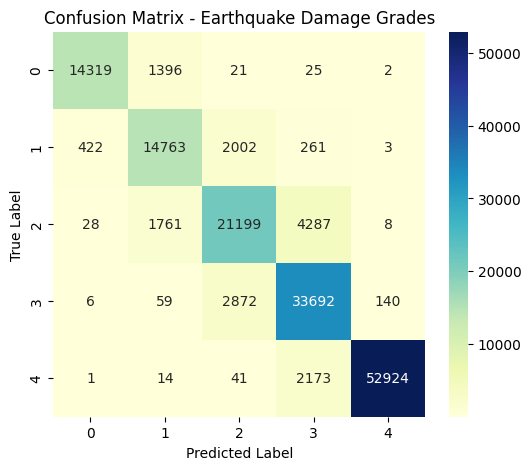

In [ ]:
# Step 7: Model Evaluation

import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Predict on test set
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

# 🔹 Metrics
acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {acc:.4f}\n")

print("📊 Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# 🔹 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Earthquake Damage Grades")
plt.show()


🏗️ Top 15 Most Important Features:

                        Feature  Importance
33               pred_intensity       11441
2                       ward_id        8638
6             plinth_area_sq_ft        7175
30                  vdcmun_name        5310
5                  age_building        4506
7              height_ft_pre_eq        4405
28  technical_solution_proposed        3941
8             height_ft_post_eq        3916
1                   vdcmun_id_x        3021
34           pred_intensity_mun        2771
27            condition_post_eq        2539
32                district_name        1682
12            ground_floor_type        1469
22    has_superstructure_timber        1427
9        land_surface_condition        1399


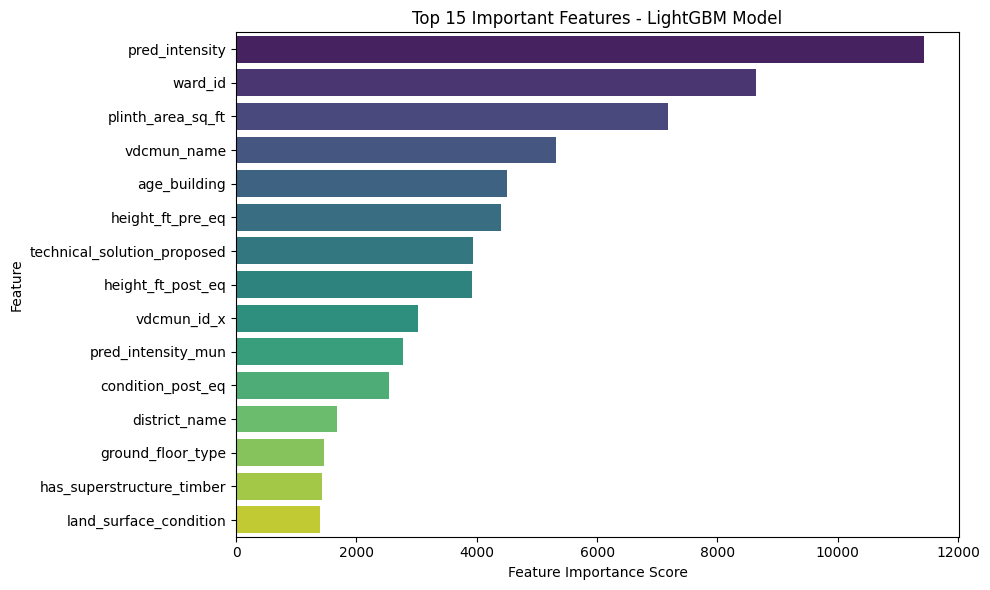

In [ ]:
# Step 8: Feature Importance Visualization

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Get feature importances from LightGBM
importance = model.feature_importance()
feature_names = X_train.columns

# 🔹 Create a dataframe for visualization
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# 🔹 Display top features
print("🏗️ Top 15 Most Important Features:\n")
print(feat_imp_df.head(15))

# 🔹 Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')
plt.title("Top 15 Important Features - LightGBM Model")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
# Step 9: Compare Actual vs Predicted Damage Grades

import pandas as pd

# 🔹 Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual_Damage_Grade': y_test.values,
    'Predicted_Damage_Grade': y_pred
})

# 🔹 Show first 10 results
print("🔍 Sample predictions (first 10):\n")
print(comparison_df.head(10))

# 🔹 Optional: Calculate how many predictions were correct
correct = (comparison_df['Actual_Damage_Grade'] == comparison_df['Predicted_Damage_Grade']).sum()
total = len(comparison_df)
print(f"\n✅ Correct Predictions: {correct} / {total} ({correct/total:.2%} accuracy on test set)")


🔍 Sample predictions (first 10):

   Actual_Damage_Grade  Predicted_Damage_Grade
0                    4                       4
1                    0                       0
2                    3                       3
3                    3                       3
4                    0                       0
5                    3                       3
6                    0                       0
7                    1                       1
8                    3                       3
9                    0                       0

✅ Correct Predictions: 136897 / 152419 (89.82% accuracy on test set)
